## ATM 523 MODULE 4 - NICK RUPRECHT

In [13]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from eofs.xarray import Eof

In [55]:
import numpy as np
import xarray as xr
from eofs.xarray import Eof

# ERA5 dataset
ds = xr.open_dataset("ATM523MOD4.nc")

if 'valid_time' in ds.coords:
    ds = ds.rename({'valid_time': 'time'})

# Converting longitude to 0–360 and sort
ds = ds.assign_coords(longitude=((ds.longitude + 360) % 360))
ds = ds.sortby("longitude")

# Pacific Basin: 65°N to 65°S, 120°E to 60°W
ds_pacific = ds.sel(latitude=slice(65, -65), longitude=slice(120, 300))

# SST and TCWV
sst = ds_pacific['sst']
tcwv = ds_pacific['tcwv']

In [56]:
# SST anomalies by removing monthly climatology
sst_clim = sst.groupby('time.month').mean('time')
sst_anom = sst.groupby('time.month') - sst_clim

# Dropping extra coordinates to avoid EOF errors
sst_clean = sst_anom.copy().drop_vars([v for v in sst_anom.coords if v not in ['time', 'latitude', 'longitude']])

# Applying sqrt(cos(lat)) weights
coslat = np.cos(np.deg2rad(sst_clean.latitude))
wgts = np.sqrt(coslat.values)[:, np.newaxis]

In [57]:
# EOF solver
solver = Eof(sst_clean, weights=wgts)

# EOFs and principal components
eofs = solver.eofsAsCorrelation(neofs=5)
pcs = solver.pcs(npcs=5, pcscaling=1)

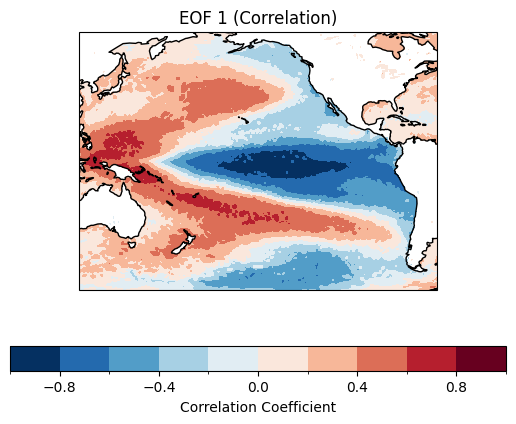

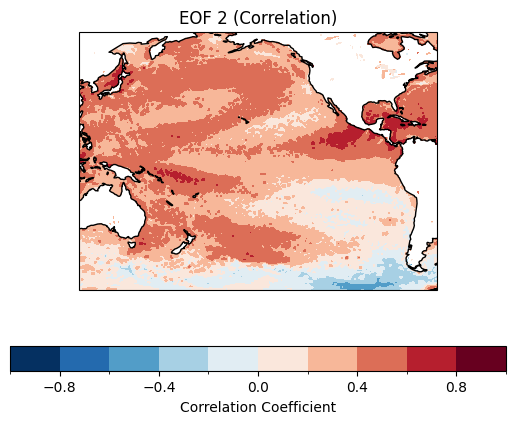

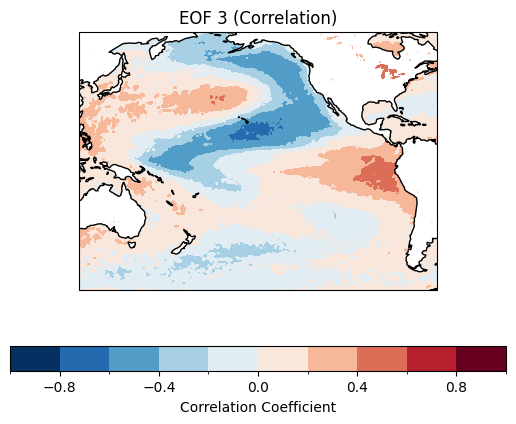

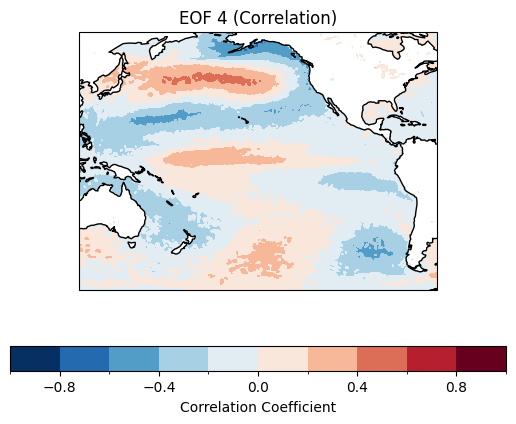

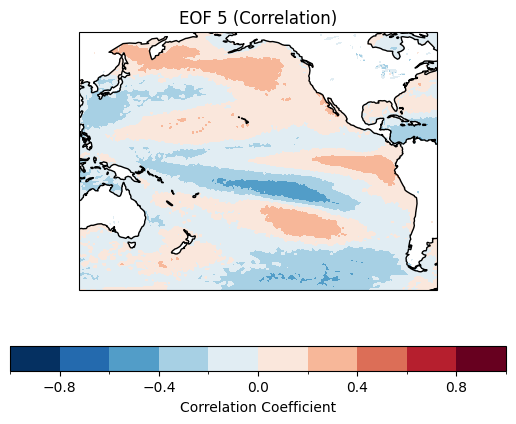

In [58]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

for i in range(5):
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
    eofs.sel(mode=i).plot.contourf(
        ax=ax,
        levels=np.linspace(-1, 1, 11),
        cmap='RdBu_r',
        transform=ccrs.PlateCarree(),
        add_colorbar=False
    )
    ax.coastlines()
    cb = plt.colorbar(ax.collections[0], orientation='horizontal')
    cb.set_label('Correlation Coefficient')
    ax.set_title(f'EOF {i+1} (Correlation)')
    plt.show()

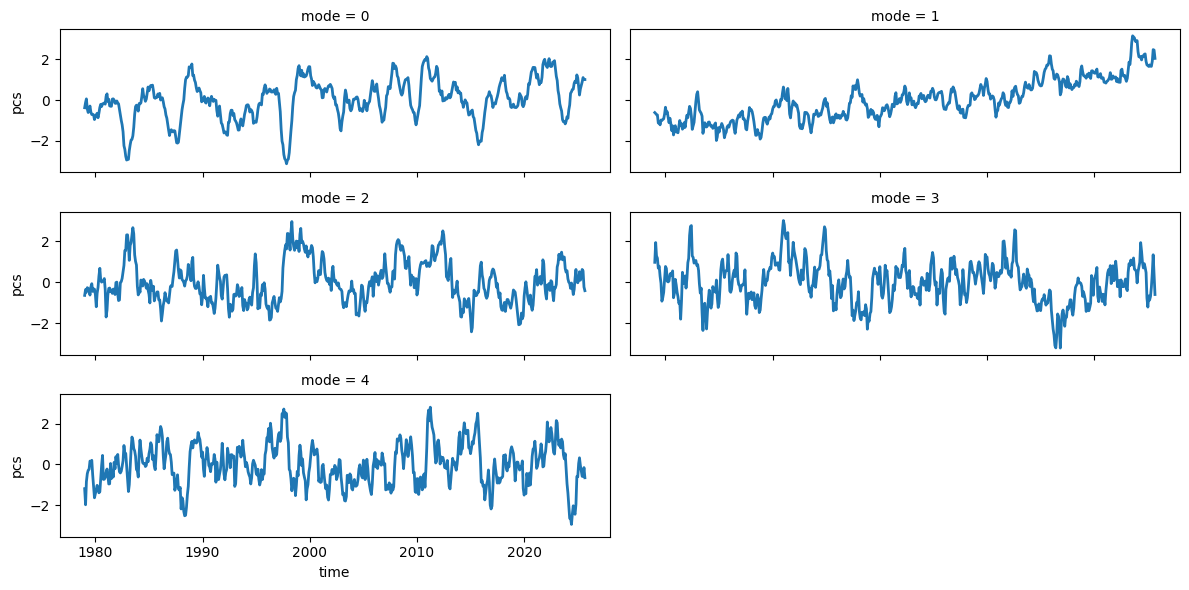

In [59]:
pcs.plot.line(x='time', col='mode', col_wrap=2, figsize=(12, 6), linewidth=2)

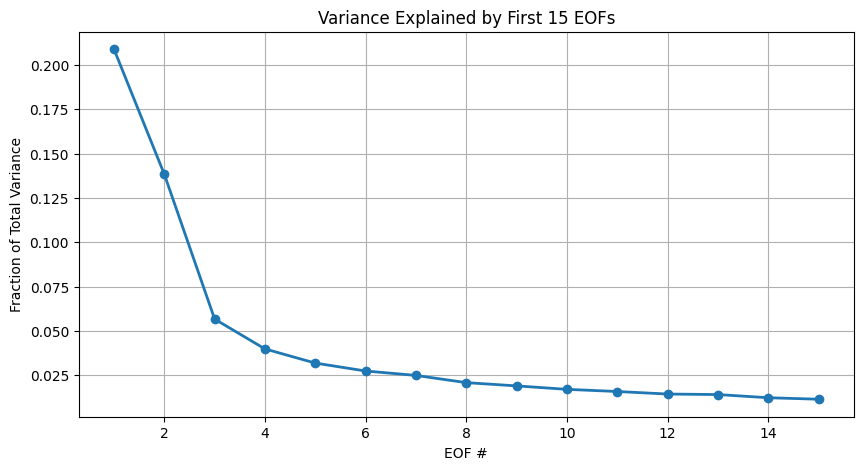

In [60]:
varfrac = solver.varianceFraction()

plt.figure(figsize=(10, 5))
plt.plot(range(1, 16), varfrac[:15], marker='o', linewidth=2)
plt.title('Variance Explained by First 15 EOFs')
plt.xlabel('EOF #')
plt.ylabel('Fraction of Total Variance')
plt.grid()
plt.show()

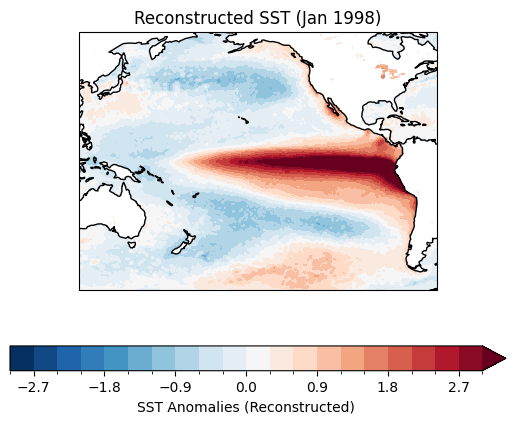

In [61]:
reconstruction = solver.reconstructedField(4)

ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=190))
reconstruction.sel(time='1998-01-15', method='nearest').plot.contourf(
    ax=ax,
    levels=np.linspace(-3, 3, 21),
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)
ax.coastlines()
cb = plt.colorbar(ax.collections[0], orientation='horizontal')
cb.set_label('SST Anomalies (Reconstructed)')
ax.set_title('Reconstructed SST (Jan 1998)')
plt.show()

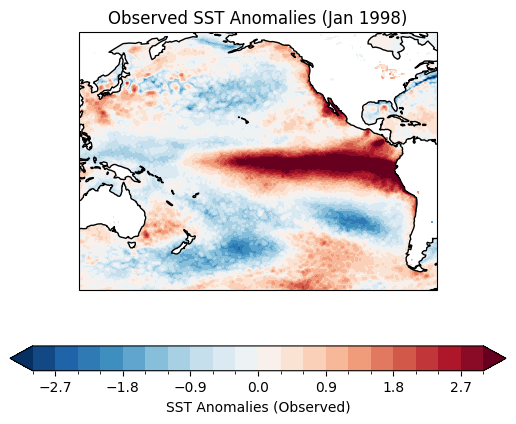

In [63]:
# Observed SST anomalies (Jan 1998)
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
sst_anom.sel(time='1998-01-15', method='nearest').plot.contourf(
    ax=ax,
    levels=np.linspace(-3, 3, 21),
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),
    cbar_kwargs={
        'label': 'SST Anomalies (Observed)',
        'orientation': 'horizontal'
    }
)
ax.coastlines()
ax.set_title('Observed SST Anomalies (Jan 1998)')
plt.show()

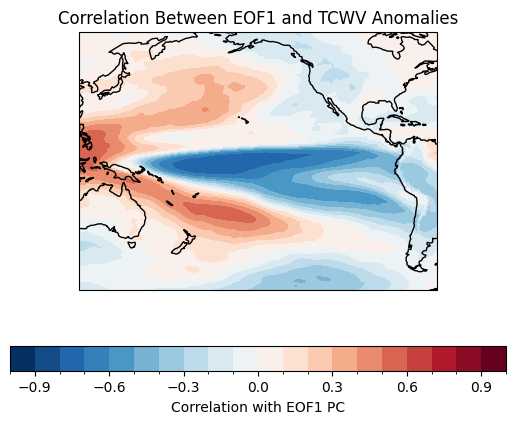

In [67]:
# Deseasonalizing and detrending TCWV
tcwv_clim = tcwv.groupby('time.month').mean('time')
tcwv_anom = tcwv.groupby('time.month') - tcwv_clim

def detrend(da):
    t = np.arange(da.time.size)
    coeffs = np.polyfit(t, da.mean(dim=['latitude', 'longitude'], skipna=True), 1)
    trend = xr.DataArray(coeffs[0] * t + coeffs[1], dims='time', coords={'time': da.time})
    return da - trend

tcwv_detrended = detrend(tcwv_anom)

tcwv_std = tcwv_detrended / tcwv_detrended.std(dim='time')

# Correlating EOF1 PC with TCWV anomalies
pc1 = pcs.sel(mode=0)
corr_map = xr.corr(pc1, tcwv_std, dim='time')

ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
corr_map.plot.contourf(
    ax=ax,
    levels=np.linspace(-1, 1, 21),
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Correlation with EOF1 PC', 'orientation': 'horizontal'}
)
ax.coastlines()
ax.set_title('Correlation Between EOF1 and TCWV Anomalies')
plt.show()

### ATMS 523 – Module 4 Project Summary  

This project uses ERA5 monthly mean data from 1979–2024 to analyze SST variability over the Pacific Basin (65°N to 65°S, 120°E to 60°W). SST and TCWV fields were masked over land and deseasonalized by removing monthly climatology. A linear detrending was applied to isolate anomalies, and SST anomalies were standardized for EOF analysis.  

EOF decomposition revealed dominant modes of SST variability, with EOF1 strongly resembling the canonical ENSO pattern. The scree plot shows EOF1 explains the largest fraction of variance. Reconstructed SST anomalies for January 1998 closely match observed anomalies, validating the EOF approach.  

Finally, a correlation map between EOF1’s principal component and TCWV anomalies shows strong coupling in the tropical Pacific, consistent with ENSO-driven atmospheric moisture variability.  